# Exploratory Data Analysis — Telecom Dataset

Dataset: `Telecom_Dataset.csv` — 50 mobile device records with hardware specs (Bluetooth, Wi-Fi, touchscreen, memory, camera, battery, screen size, weight) and `Price`.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [1]:
df = pd.read_csv('Telecom_Dataset.csv')
df.head()

       PID Blue Wi_Fi Tch_Scr Ext_Mem  Px_h  Px_w  Scr_h  Scr_w  PC  FC  Int_Mem  Bty_Pwr  RAM  Depth  Weight  Price
0  AAB346A  yes   yes      no      no   780   460      3      1   2   2        8     2800    2      7     320   3297
1  AAC347I  yes   yes      no      no   780   560      2      1   4   2        8     3000    2      7     280   4500
2  BAB657J   no   yes      no      no   840   720      2      1   4   2        8     3300    2      7     400   4898
3  BBD456K   no   yes     yes      no  1280  1120      5      3   6   2       32     3000    2      3     300   6900
4  CCP761U   no   yes     yes      no  1280  1080      4      3   6   2       16     3000    2      3     210   5600

## 2. Basic Structure

In [1]:
df.shape

(50, 17)

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   PID      50 non-null     str  
 1   Blue     50 non-null     str  
 2   Wi_Fi    50 non-null     str  
 3   Tch_Scr  50 non-null     str  
 4   Ext_Mem  50 non-null     str  
 5   Px_h     50 non-null     int64
 6   Px_w     50 non-null     int64
 7   Scr_h    50 non-null     int64
 8   Scr_w    50 non-null     int64
 9   PC       50 non-null     int64
 10  FC       50 non-null     int64
 11  Int_Mem  50 non-null     int64
 12  Bty_Pwr  50 non-null     int64
 13  RAM      50 non-null     int64
 14  Depth    50 non-null     int64
 15  Weight   50 non-null     int64
 16  Price    50 non-null     int64
dtypes: int64(12), str(5)
memory usage: 6.8 KB


In [1]:
df.describe()

              Px_h         Px_w      Scr_h      Scr_w          PC         FC      Int_Mem      Bty_Pwr        RAM      Depth      Weight          Price
count    50.000000    50.000000  50.000000  50.000000   50.000000  50.000000    50.000000    50.000000  50.000000  50.000000   50.000000      50.000000
mean   2319.400000  1833.200000   6.500000   4.620000   42.160000  20.760000   173.760000  3740.000000   5.760000   3.440000  195.200000   33794.860000
std     598.400623   469.713069   2.042907   1.883223   30.174567  14.784934   261.771871   958.817299   2.759473   1.052887   75.761171   25037.535393
min     780.000000   460.000000   2.000000   1.000000    2.000000   2.000000     8.000000  2300.000000   2.000000   2.000000   80.000000    3297.000000
25%    2080.000000  1775.000000   5.000000   3.000000   12.000000   8.000000    32.000000  2800.000000   4.000000   3.000000  142.500000   19126.500000
50%    2580.000000  1980.000000   6.000000   5.000000   40.000000  16.000000    64.00000

## 3. Data Quality Checks

In [1]:
df.isnull().sum()

PID        0
Blue       0
Wi_Fi      0
Tch_Scr    0
Ext_Mem    0
Px_h       0
Px_w       0
Scr_h      0
Scr_w      0
PC         0
FC         0
Int_Mem    0
Bty_Pwr    0
RAM        0
Depth      0
Weight     0
Price      0

In [1]:
df.duplicated().sum()

0

No missing values and no duplicate rows — the dataset is already clean.

## 4. Binary Feature Columns

In [1]:
binary_cols = ['Blue', 'Wi_Fi', 'Tch_Scr', 'Ext_Mem']
for c in binary_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts())

--- Blue ---
Blue
yes    27
no     23
--- Wi_Fi ---
Wi_Fi
yes    42
no      8
--- Tch_Scr ---
Tch_Scr
yes    45
no      5
--- Ext_Mem ---
Ext_Mem
yes    38
no     12

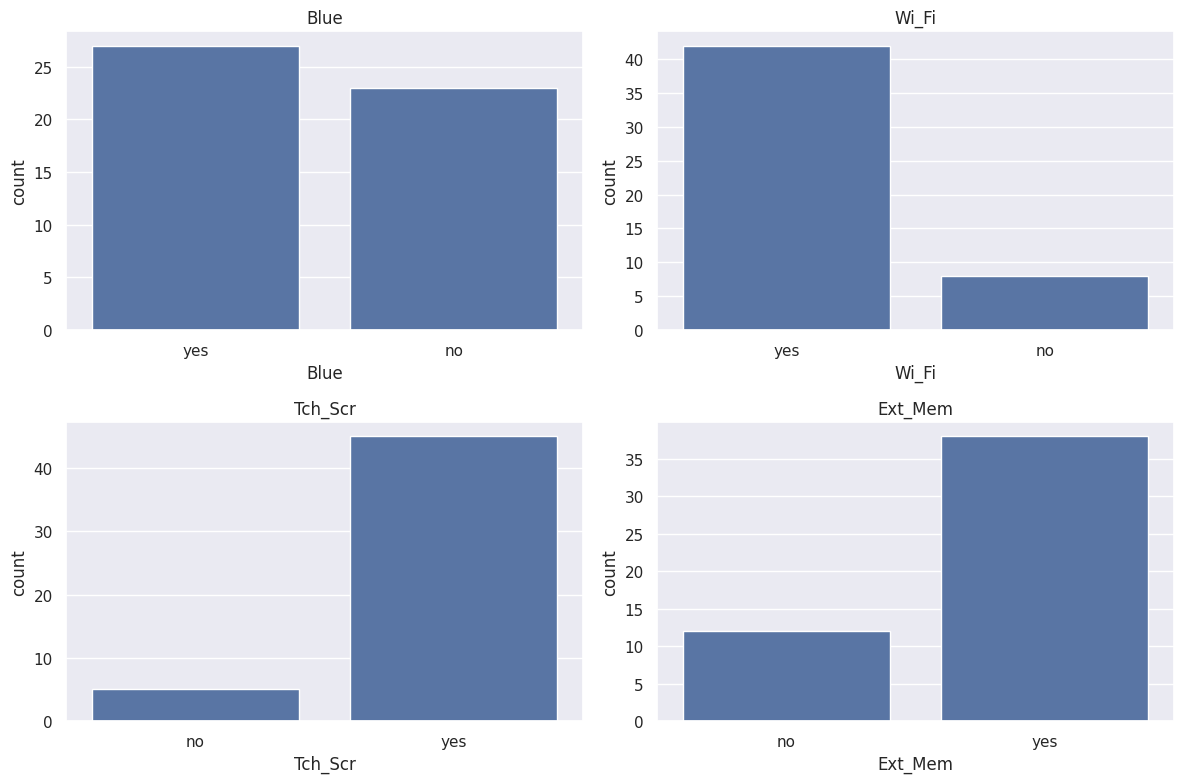

In [1]:
plt.figure(figsize=(12,8))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

## 5. Outlier Detection (IQR method)

In [1]:
numeric_cols = [c for c in df.columns if c not in ['PID'] + binary_cols]

In [1]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | (df[numeric_cols] > (Q3 + 1.5*IQR))).any(axis=1)
df_no_outliers = df[~outlier_mask]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)
print("Outlier rows removed:", outlier_mask.sum())

Original shape: (50, 17)
After removing outliers: (35, 17)
Outlier rows removed: 15

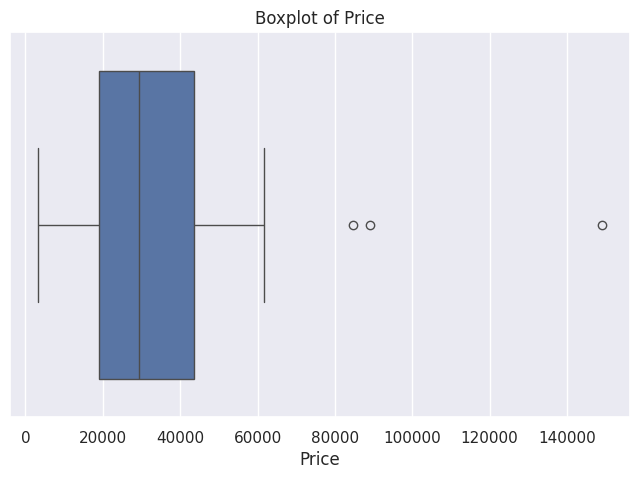

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title('Boxplot of Price')
plt.show()

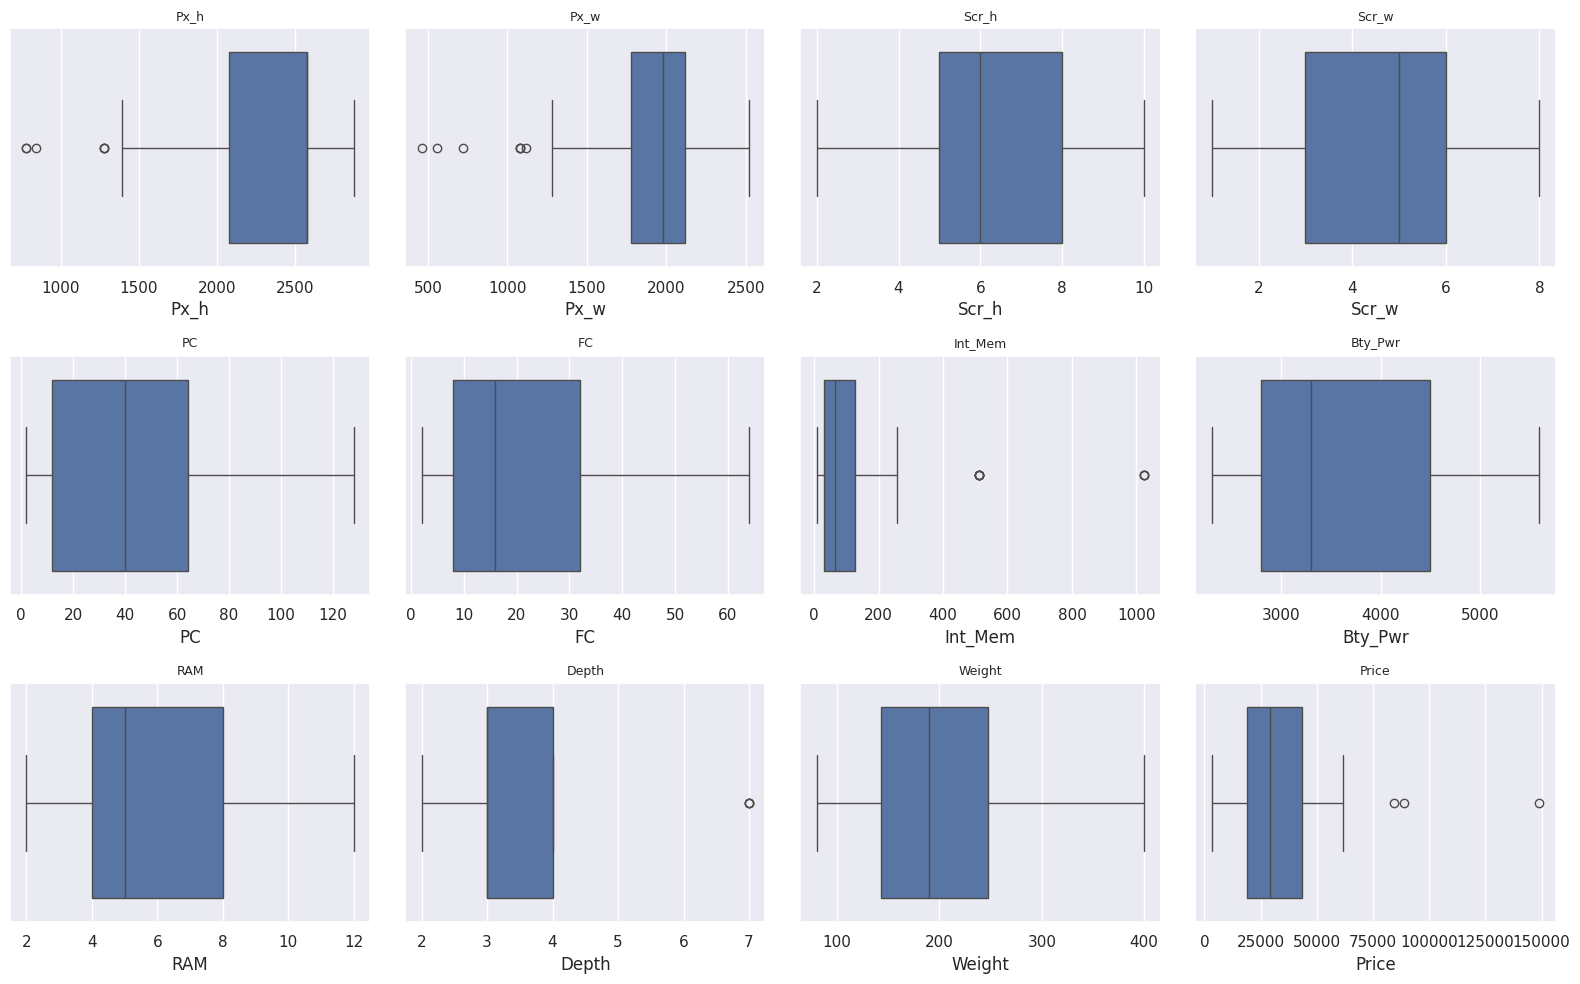

In [1]:
plt.figure(figsize=(16,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Univariate Distributions

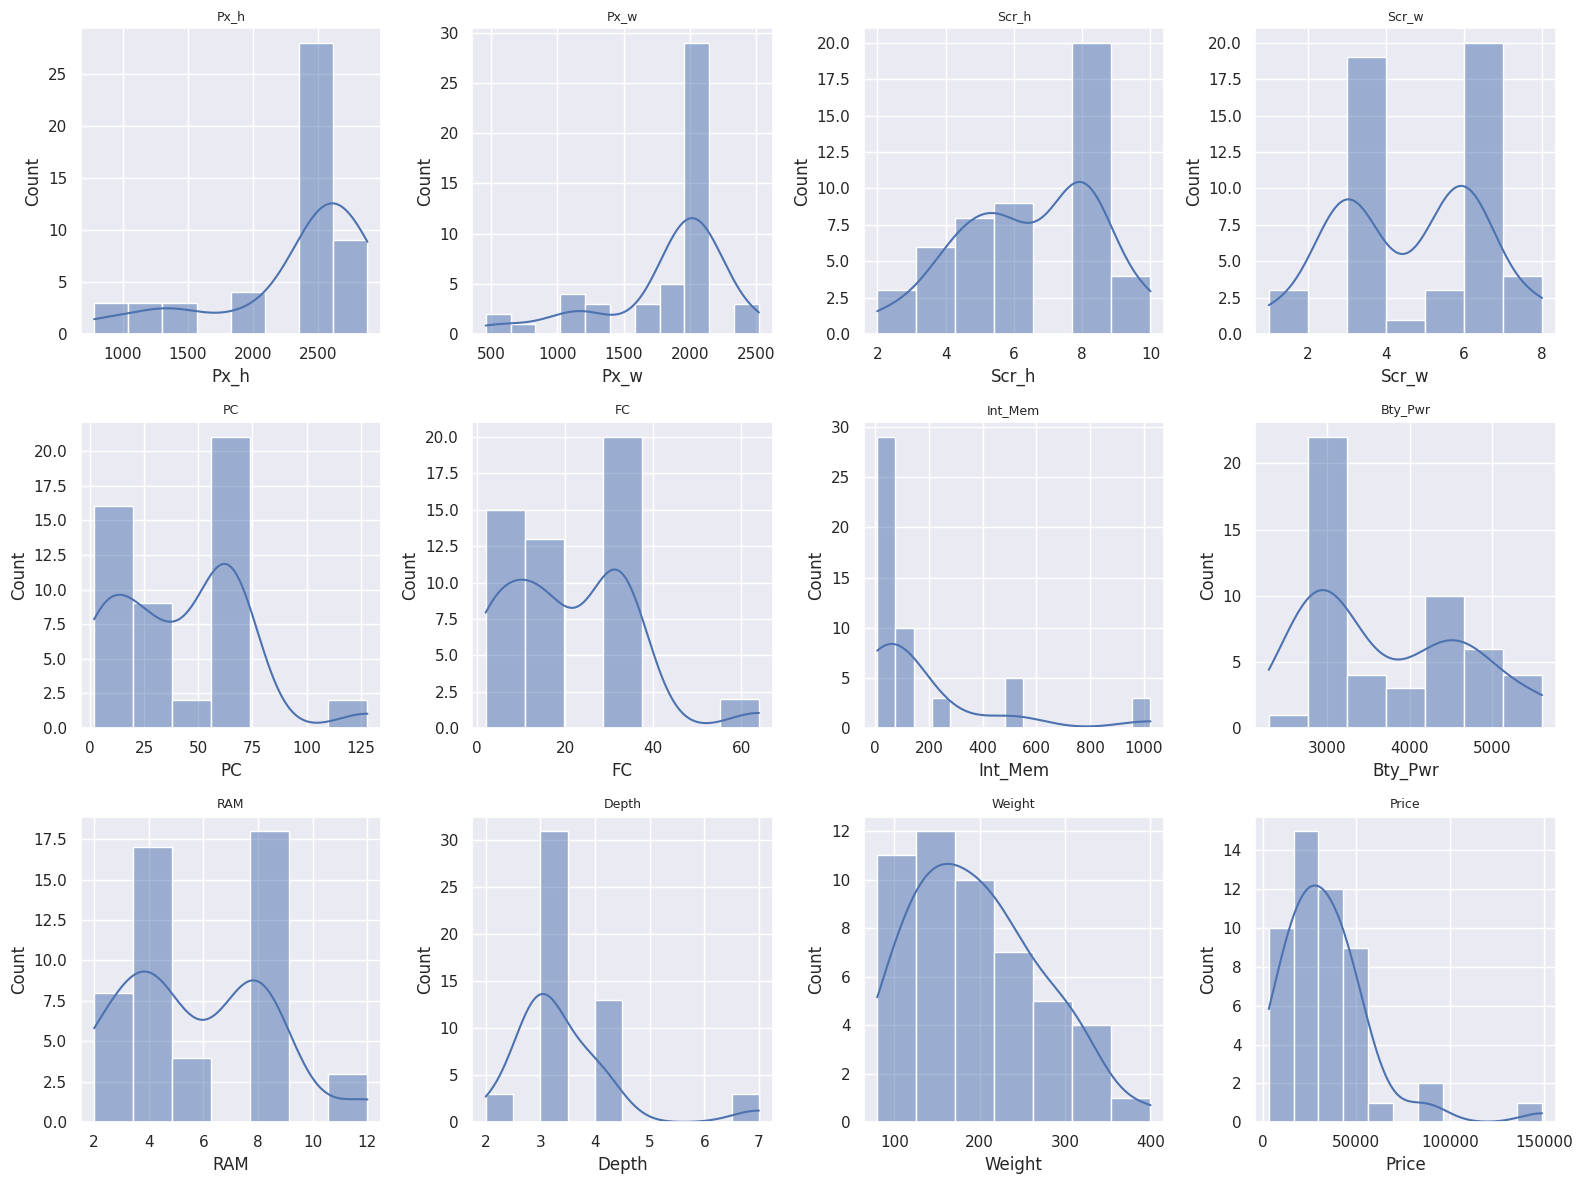

In [1]:
plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Price by Binary Features

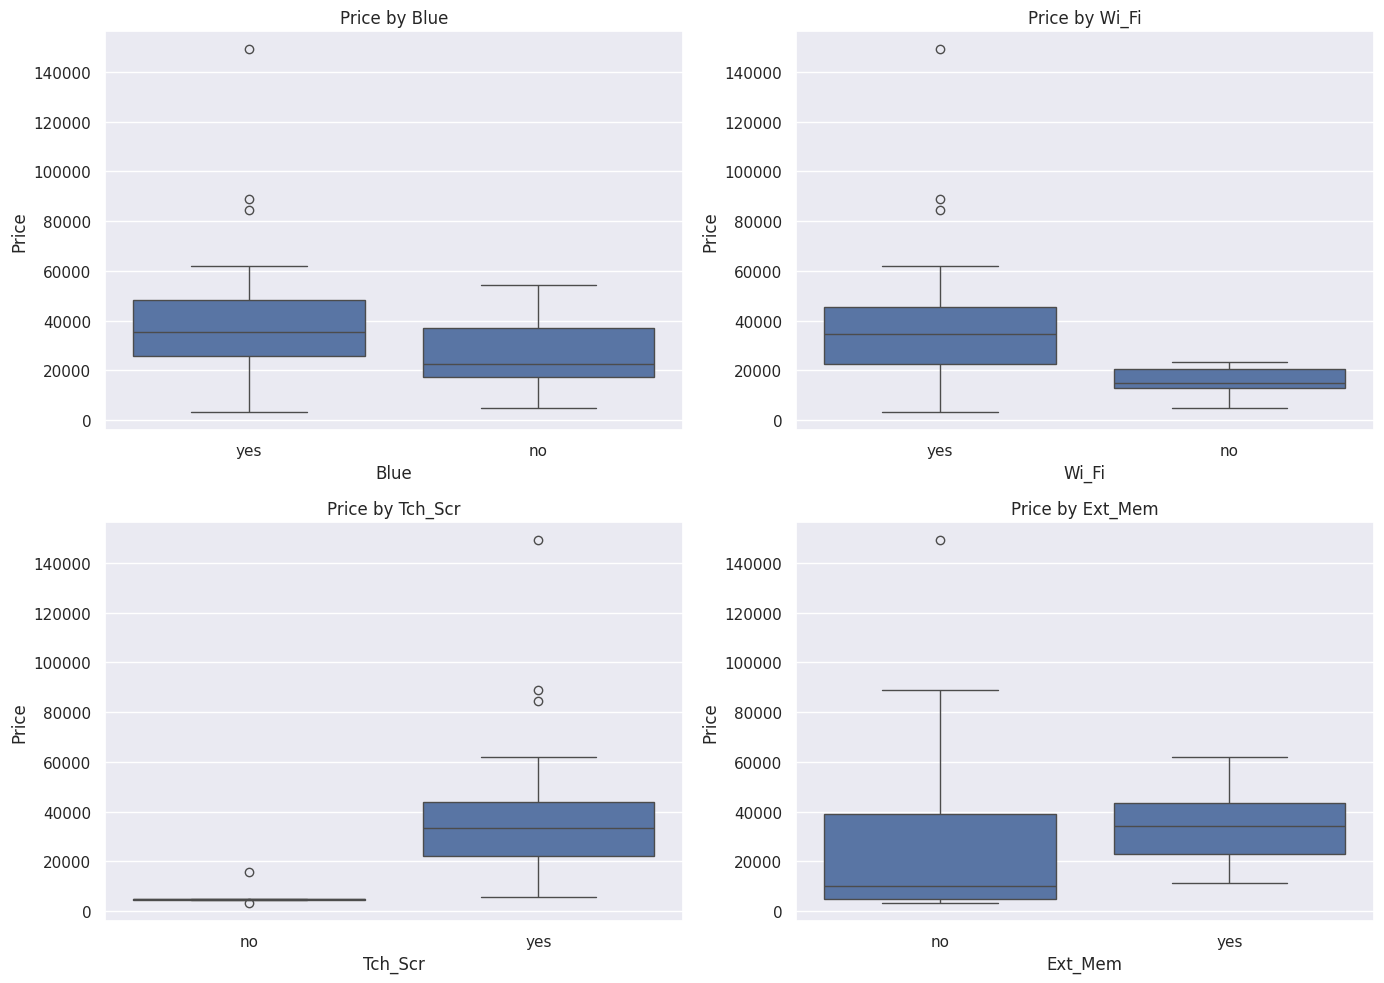

In [1]:
plt.figure(figsize=(14,10))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=col, y='Price', data=df)
    plt.title(f'Price by {col}')
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

In [1]:
corr = df[numeric_cols].corr()
corr

             Px_h      Px_w     Scr_h     Scr_w        PC        FC   Int_Mem   Bty_Pwr       RAM     Depth    Weight     Price
Px_h     1.000000  0.962988  0.619936  0.582562  0.634229  0.619173  0.328951  0.391626  0.495757 -0.555409 -0.394854  0.546202
Px_w     0.962988  1.000000  0.651433  0.629169  0.697908  0.680534  0.416436  0.445295  0.591360 -0.632620 -0.430937  0.635222
Scr_h    0.619936  0.651433  1.000000  0.962787  0.420454  0.395268  0.400244  0.421755  0.448901 -0.531327 -0.292726  0.376118
Scr_w    0.582562  0.629169  0.962787  1.000000  0.392552  0.368270  0.393009  0.390155  0.414077 -0.510919 -0.227604  0.345074
PC       0.634229  0.697908  0.420454  0.392552  1.000000  0.966222  0.575898  0.599042  0.612231 -0.395388 -0.257475  0.775305
FC       0.619173  0.680534  0.395268  0.368270  0.966222  1.000000  0.586221  0.573891  0.588815 -0.368024 -0.295842  0.773323
Int_Mem  0.328951  0.416436  0.400244  0.393009  0.575898  0.586221  1.000000  0.641622  0.579205 -0.357

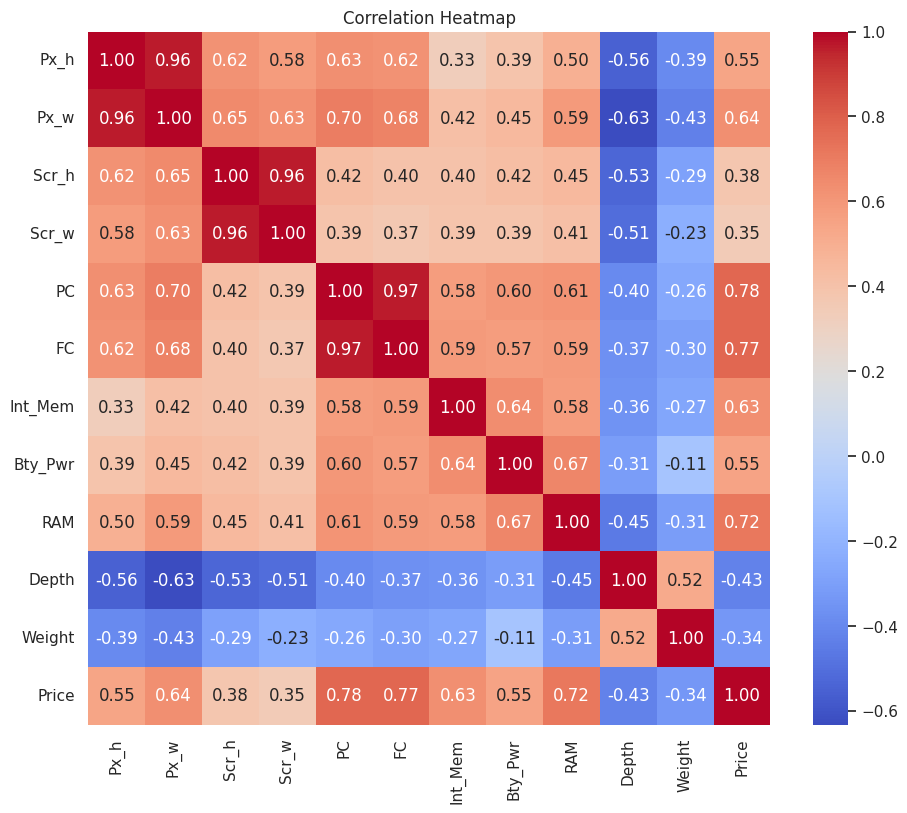

In [1]:
plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [1]:
corr_price = corr['Price'].drop('Price').sort_values(ascending=False)
corr_price

PC         0.775305
FC         0.773323
RAM        0.715880
Px_w       0.635222
Int_Mem    0.631335
Bty_Pwr    0.549662
Px_h       0.546202
Scr_h      0.376118
Scr_w      0.345074
Weight    -0.335719
Depth     -0.425357

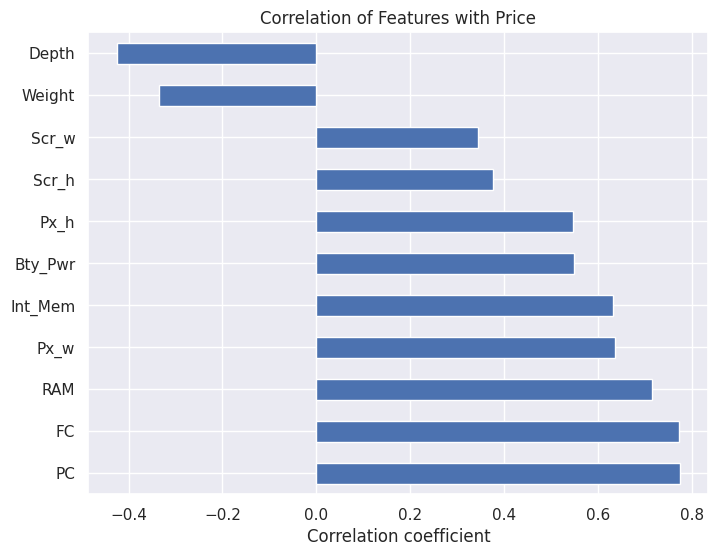

In [1]:
plt.figure(figsize=(8,6))
corr_price.plot(kind='barh')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

## 9. Bivariate Analysis

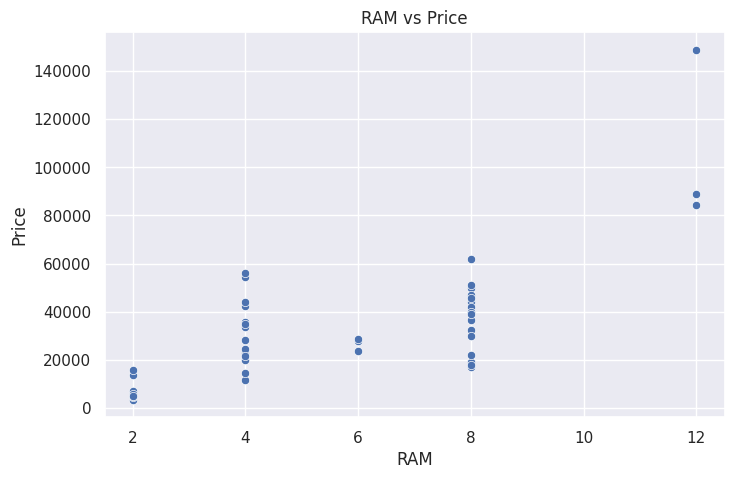

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='RAM', y='Price', data=df)
plt.title('RAM vs Price')
plt.show()

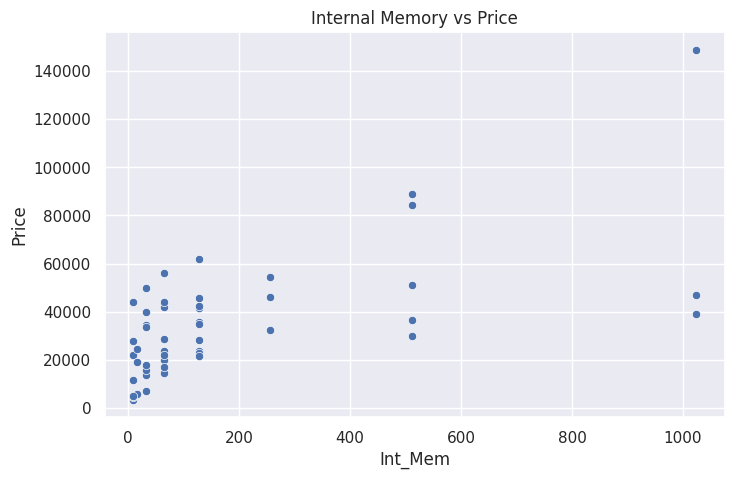

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Int_Mem', y='Price', data=df)
plt.title('Internal Memory vs Price')
plt.show()

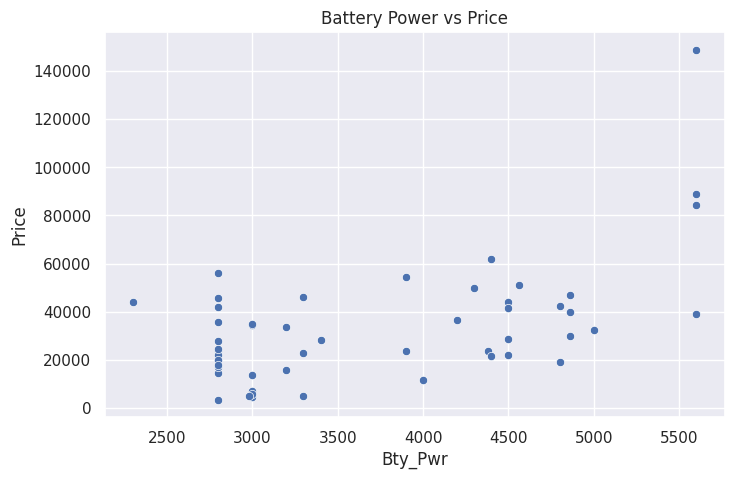

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Bty_Pwr', y='Price', data=df)
plt.title('Battery Power vs Price')
plt.show()

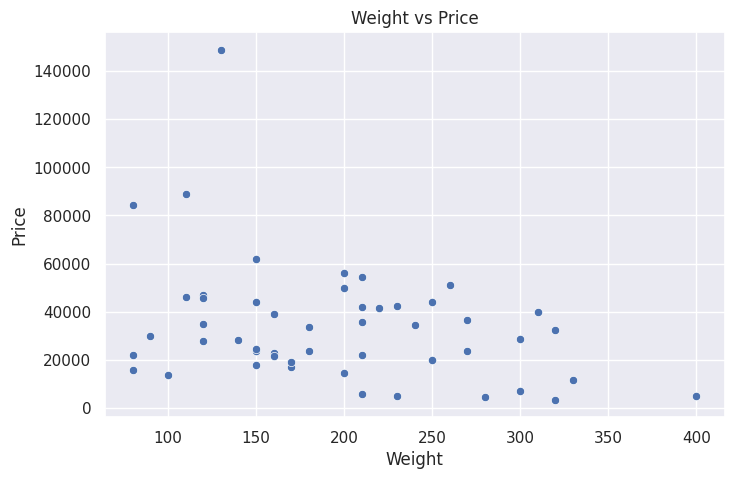

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Weight', y='Price', data=df)
plt.title('Weight vs Price')
plt.show()

## 10. Summary

- **50 records, 17 columns**, no missing values, no duplicates — dataset is already clean.
- Four binary hardware features: Bluetooth, Wi-Fi, touchscreen, and expandable memory, roughly split between yes/no.
- IQR-based outlier check: see the printed shapes above for how many rows would be flagged.
- Correlation with `Price` (see the ranked bar chart above): **primary camera (PC)**, **front camera (FC)**, and **RAM** are the strongest positive correlates, while **Depth** and **Weight** correlate negatively — thinner, lighter devices with better cameras and more RAM tend to be priced higher in this sample.